# Analise de `--max-chars` com base nos dados fonte

Este notebook analisa as paginas limpas em `data/interim/hoi4_wiki/pages/` antes do chunking.

Objetivo: extrair metricas de tamanho natural de secoes e blocos para escolher candidatos melhores de `--max-chars`.

In [1]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 100)

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "interim" / "hoi4_wiki" / "pages").exists():
            return candidate
    raise FileNotFoundError("Nao encontrei data/interim/hoi4_wiki/pages a partir do diretorio atual.")

ROOT = find_project_root(Path.cwd())
PAGES_DIR = ROOT / "data" / "interim" / "hoi4_wiki" / "pages"
OUTPUT_DIR = ROOT / "avaliacao" / "outputs" / "max_chars"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ROOT, PAGES_DIR, OUTPUT_DIR

(PosixPath('/home/joaocrm/projects/norta-llm-hoi4-commander'),
 PosixPath('/home/joaocrm/projects/norta-llm-hoi4-commander/data/interim/hoi4_wiki/pages'),
 PosixPath('/home/joaocrm/projects/norta-llm-hoi4-commander/avaliacao/outputs/max_chars'))

## 1. Funcoes de parsing simples

A ideia aqui nao e reproduzir todo o chunker, mas medir o tamanho natural dos textos fonte.

In [2]:
HEADING_RE = re.compile(r"^(#{1,6})\s+(.+?)\s*$")
WORD_RE = re.compile(r"\w+", re.UNICODE)
LIST_RE = re.compile(r"^\s*(?:[-*+]\s+|\d+[.)]\s+)")
TABLE_RE = re.compile(r"^\s*\|")

def strip_front_matter(text: str) -> str:
    lines = text.splitlines()
    if lines and lines[0].strip() == "---":
        for index, line in enumerate(lines[1:], start=1):
            if line.strip() == "---":
                return "\n".join(lines[index + 1:])
    return text

def split_sections(markdown: str) -> list[dict]:
    sections = []
    heading_stack = []
    current_lines = []
    current_path = []

    def save_current() -> None:
        if current_lines:
            sections.append({
                "section_path": current_path.copy(),
                "text": "\n".join(current_lines).strip(),
            })

    for raw_line in markdown.splitlines():
        line = raw_line.rstrip()
        match = HEADING_RE.match(line.strip())
        if match:
            save_current()
            level = len(match.group(1))
            title = match.group(2).strip()
            while heading_stack and heading_stack[-1][0] >= level:
                heading_stack.pop()
            heading_stack.append((level, title))
            current_path = [item[1] for item in heading_stack]
            current_lines = [line]
            continue

        if not current_lines and not line.strip():
            continue
        current_lines.append(line)

    save_current()
    return [section for section in sections if section["text"].strip()]

def split_blocks(section_text: str) -> list[str]:
    blocks = []
    current = []
    for line in section_text.splitlines():
        if line.strip():
            current.append(line.rstrip())
        elif current:
            blocks.append("\n".join(current).strip())
            current = []
    if current:
        blocks.append("\n".join(current).strip())
    return [block for block in blocks if block.strip()]

def classify_block(block: str) -> str:
    lines = [line for line in block.splitlines() if line.strip()]
    if lines and all(TABLE_RE.match(line) for line in lines[: min(3, len(lines))]):
        return "table"
    if any(LIST_RE.match(line) for line in lines):
        return "list"
    if lines and HEADING_RE.match(lines[0].strip()):
        return "heading_block"
    return "paragraph"

def count_words(text: str) -> int:
    return len(WORD_RE.findall(text))

## 2. Carregar medidas de secoes e blocos

In [3]:
rows = []
page_paths = sorted(PAGES_DIR.glob("*.md"))

for path in page_paths:
    markdown = strip_front_matter(path.read_text(encoding="utf-8"))
    sections = split_sections(markdown)
    for section_index, section in enumerate(sections, start=1):
        section_text = section["text"]
        section_path = section["section_path"]
        rows.append({
            "type": "section",
            "block_type": "section",
            "source_path": str(path),
            "page": path.name,
            "section_index": section_index,
            "section_path": " > ".join(section_path),
            "chars": len(section_text),
            "words": count_words(section_text),
            "line_count": len(section_text.splitlines()),
        })

        for block_index, block in enumerate(split_blocks(section_text), start=1):
            rows.append({
                "type": "block",
                "block_type": classify_block(block),
                "source_path": str(path),
                "page": path.name,
                "section_index": section_index,
                "block_index": block_index,
                "section_path": " > ".join(section_path),
                "chars": len(block),
                "words": count_words(block),
                "line_count": len(block.splitlines()),
            })

base_df = pd.DataFrame(rows)
base_path = OUTPUT_DIR / "base_tamanhos_secoes_blocos.csv"
base_df.to_csv(base_path, index=False)

print(f"Paginas analisadas: {len(page_paths)}")
print(f"Linhas medidas: {len(base_df)}")
print(f"CSV salvo em: {base_path}")
base_df.head()

Paginas analisadas: 2357
Linhas medidas: 128023
CSV salvo em: /home/joaocrm/projects/norta-llm-hoi4-commander/avaliacao/outputs/max_chars/base_tamanhos_secoes_blocos.csv


,type,block_type,source_path,page,section_index,section_path,chars,words,line_count,block_index
0,section,section,/home/joaocrm/projects/norta-llm-hoi4-commander/data/interim/hoi4_wiki/pages/00001-patch-1-16.md,00001-patch-1-16.md,1,Graveyard of Empires,309,50,8,NaN
1,block,list,/home/joaocrm/projects/norta-llm-hoi4-commander/data/interim/hoi4_wiki/pages/00001-patch-1-16.md,00001-patch-1-16.md,1,Graveyard of Empires,309,50,8,1.0
2,section,section,/home/joaocrm/projects/norta-llm-hoi4-commander/data/interim/hoi4_wiki/pages/00001-patch-1-16.md,00001-patch-1-16.md,2,Gameplay,499,83,10,NaN
3,block,list,/home/joaocrm/projects/norta-llm-hoi4-commander/data/interim/hoi4_wiki/pages/00001-patch-1-16.md,00001-patch-1-16.md,2,Gameplay,499,83,10,1.0
4,section,section,/home/joaocrm/projects/norta-llm-hoi4-commander/data/interim/hoi4_wiki/pages/00001-patch-1-16.md,00001-patch-1-16.md,3,Balance,372,60,9,NaN


## 3. Percentis de tamanho

Use principalmente os percentis de `block`, porque o chunker semantico trabalha a partir de unidades menores dentro das secoes.

In [4]:
percentiles = [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
size_stats = base_df.groupby("type")[["chars", "words", "line_count"]].describe(percentiles=percentiles)
size_stats

chars                                                        \
           count         mean          std  min    25%     50%     75%   
type                                                                     
block    64020.0  3010.109934  9199.713750  3.0  232.0  1050.5  2351.0   
section  64003.0  3010.909989  9200.811858  3.0  232.0  1052.0  2352.0   

                                   ... line_count                            \
            90%      95%      99%  ...       mean        std  min  25%  50%   
type                               ...                                        
block    5923.0  12335.0  35421.0  ...  15.022009  45.591184  1.0  3.0  9.0   
section  5923.0  12335.0  35421.0  ...  15.026264  45.597024  1.0  3.0  9.0   

                                          
          75%   90%   95%   99%      max  
type                                      
block    25.0  32.0  36.0  71.0  10256.0  
section  25.0  32.0  36.0  71.0  10256.0  

[2 rows x 33 columns]

In [5]:
block_type_stats = (
    base_df[base_df["type"] == "block"]
    .groupby("block_type")[["chars", "words", "line_count"]]
    .describe(percentiles=percentiles)
)
block_type_stats

chars                                                     \
                 count          mean            std    min    25%     50%   
block_type                                                                  
heading_block  59822.0   3002.870683    8465.169363    3.0  198.0  1026.0   
list            4121.0   2442.356710    8305.574076   34.0  629.0  1592.0   
paragraph         37.0  80631.108108  131521.713120   10.0  388.0  1450.0   
table             40.0    530.125000    1381.416760  293.0  294.5   311.0   

                                                        ...  line_count  \
                    75%       90%       95%        99%  ...        mean   
block_type                                              ...               
heading_block    2309.0    6211.0   12882.6   35421.00  ...   14.419210   
list             2799.0    4680.0    6157.0   14274.00  ...   22.148750   
paragraph      108222.0  261499.8  348579.0  504035.32  ...  210.297297   
table             323.0     333.6     339.7    5656.95  ...    1.675000   

                                                                          \
                      std  min  25%   50%    75%    90%     95%      99%   
block_type                                                                 
heading_block   17.708853  1.0  2.0   9.0   26.0   32.0    36.0    65.00   
list           162.043707  2.0  7.0  12.0   23.0   41.0    60.0   108.80   
paragraph      352.514528  1.0  2.0  21.0  208.0  673.6  1065.6  1287.52   
table            4.269075  1.0  1.0   1.0    1.0    1.0     1.0    17.47   

                        
                   max  
block_type              
heading_block    831.0  
list           10256.0  
paragraph       1402.0  
table             28.0  

[4 rows x 33 columns]

## 4. Cobertura por candidatos de `--max-chars`

In [6]:
CANDIDATES = [800, 1000, 1200, 1400, 1600, 1800, 2000, 2500, 3000]

summary_rows = []
for max_chars in CANDIDATES:
    for item_type in ["block", "section"]:
        subset = base_df[base_df["type"] == item_type]
        summary_rows.append({
            "max_chars": max_chars,
            "type": item_type,
            "items": len(subset),
            "covered_pct": (subset["chars"] <= max_chars).mean() * 100,
            "above_limit_pct": (subset["chars"] > max_chars).mean() * 100,
            "items_above_limit": int((subset["chars"] > max_chars).sum()),
        })

coverage_df = pd.DataFrame(summary_rows)
coverage_path = OUTPUT_DIR / "cobertura_max_chars.csv"
coverage_df.to_csv(coverage_path, index=False)
print(f"CSV salvo em: {coverage_path}")
coverage_df

CSV salvo em: /home/joaocrm/projects/norta-llm-hoi4-commander/avaliacao/outputs/max_chars/cobertura_max_chars.csv


,max_chars,type,items,covered_pct,above_limit_pct,items_above_limit
0,800,block,64020,39.090909,60.909091,38994
1,800,section,64003,39.068481,60.931519,38998
2,1000,block,64020,48.634802,51.365198,32884
3,1000,section,64003,48.618034,51.381966,32886
4,1200,block,64020,53.283349,46.716651,29908
5,1200,section,64003,53.269378,46.730622,29909
6,1400,block,64020,60.068729,39.931271,25564
7,1400,section,64003,60.056560,39.943440,25565
8,1600,block,64020,64.234614,35.765386,22897
9,1600,section,64003,64.221990,35.778010,22899


In [7]:
pivot_coverage = coverage_df.pivot(index="max_chars", columns="type", values="covered_pct")
pivot_coverage

type,block,section
max_chars,,
800,39.090909,39.068481
1000,48.634802,48.618034
1200,53.283349,53.269378
1400,60.068729,60.056560
1600,64.234614,64.221990
1800,68.175570,68.163992
2000,71.424555,71.415402
2500,76.654171,76.647970
3000,80.190565,80.185304


## 5. Graficos

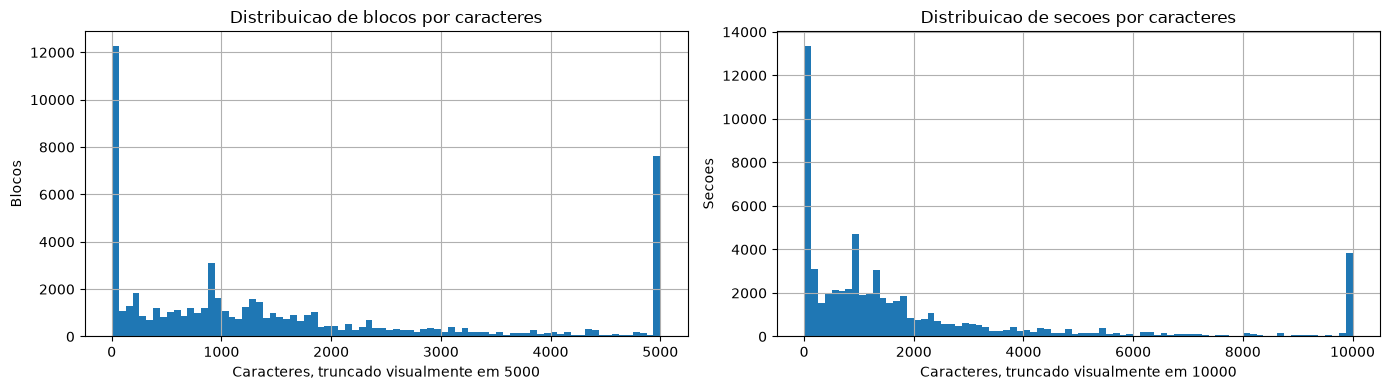

Grafico salvo em: /home/joaocrm/projects/norta-llm-hoi4-commander/avaliacao/outputs/max_chars/histogramas_tamanho_base.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

base_df[base_df["type"] == "block"]["chars"].clip(upper=5000).hist(bins=80, ax=axes[0])
axes[0].set_title("Distribuicao de blocos por caracteres")
axes[0].set_xlabel("Caracteres, truncado visualmente em 5000")
axes[0].set_ylabel("Blocos")

base_df[base_df["type"] == "section"]["chars"].clip(upper=10000).hist(bins=80, ax=axes[1])
axes[1].set_title("Distribuicao de secoes por caracteres")
axes[1].set_xlabel("Caracteres, truncado visualmente em 10000")
axes[1].set_ylabel("Secoes")

plt.tight_layout()
hist_path = OUTPUT_DIR / "histogramas_tamanho_base.png"
plt.savefig(hist_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Grafico salvo em: {hist_path}")

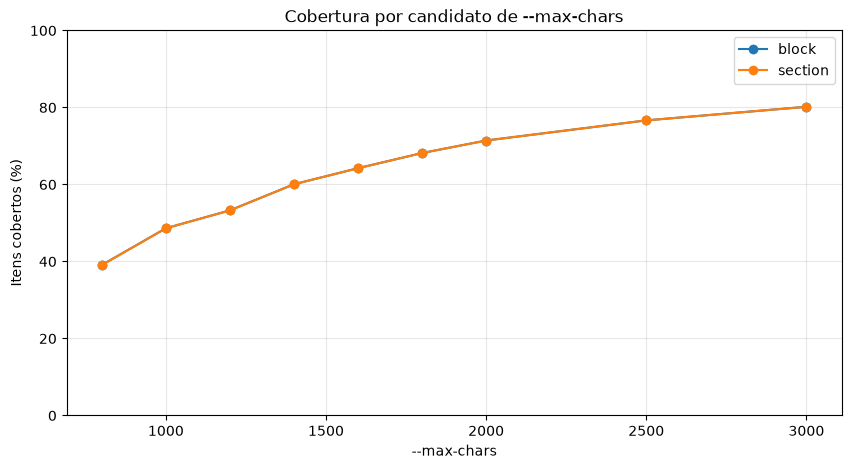

Grafico salvo em: /home/joaocrm/projects/norta-llm-hoi4-commander/avaliacao/outputs/max_chars/cobertura_por_max_chars.png


In [9]:
plt.figure(figsize=(10, 5))
for item_type, group in coverage_df.groupby("type"):
    plt.plot(group["max_chars"], group["covered_pct"], marker="o", label=item_type)

plt.title("Cobertura por candidato de --max-chars")
plt.xlabel("--max-chars")
plt.ylabel("Itens cobertos (%)")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()

coverage_plot_path = OUTPUT_DIR / "cobertura_por_max_chars.png"
plt.savefig(coverage_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Grafico salvo em: {coverage_plot_path}")

## 6. Sugestao automatica de candidatos

A sugestao abaixo usa percentis dos blocos naturais:

- p75: candidato mais preciso;
- p90: candidato equilibrado;
- p95: candidato mais contextual.

In [10]:
blocks = base_df[base_df["type"] == "block"]
quantiles = blocks["chars"].quantile([0.75, 0.90, 0.95]).round().astype(int)

suggestions = pd.DataFrame([
    {"profile": "preciso", "basis": "p75 blocos", "suggested_max_chars": int(quantiles.loc[0.75])},
    {"profile": "equilibrado", "basis": "p90 blocos", "suggested_max_chars": int(quantiles.loc[0.90])},
    {"profile": "contextual", "basis": "p95 blocos", "suggested_max_chars": int(quantiles.loc[0.95])},
])

suggestions["rounded_to_nearest_100"] = (suggestions["suggested_max_chars"] / 100).round().astype(int) * 100
suggestions_path = OUTPUT_DIR / "sugestoes_max_chars.csv"
suggestions.to_csv(suggestions_path, index=False)
print(f"CSV salvo em: {suggestions_path}")
suggestions

CSV salvo em: /home/joaocrm/projects/norta-llm-hoi4-commander/avaliacao/outputs/max_chars/sugestoes_max_chars.csv


,profile,basis,suggested_max_chars,rounded_to_nearest_100
0,preciso,p75 blocos,2351,2400
1,equilibrado,p90 blocos,5923,5900
2,contextual,p95 blocos,12335,12300


## Como interpretar

Use a coluna `block.covered_pct` para escolher candidatos de teste:

- se um valor cobre 85-90% dos blocos, ele costuma ser um bom ponto inicial;
- se um valor cobre quase todos os blocos mas gera chunks grandes demais, teste o candidato anterior;
- se muitos blocos naturais excedem 3000 caracteres, talvez o problema seja tratamento de tabelas/listas, nao apenas `--max-chars`.

Depois rode o chunking real com 2 ou 3 candidatos e compare no notebook de avaliacao de chunks.